##### `Stape 1 : Prepare The Data`

In [1]:
"""IMPORT EVERYTHING.. """
# Data manipulation
import pandas as pd
import numpy as np

# # Quantitative analysis / indicators
# import talib
# import backtrader as bt

# # Machine learning / statistics
# import scipy
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression

# # Visualization
# import matplotlib.pyplot as plt
# import seaborn as sns
import mplfinance as mpf

# # Jupyter Notebook magic for inline plots
# %matplotlib inline


In [2]:
"""Load Source OHLCV dta"""

df = pd.read_csv("../Src/GBPUSDc_H1.csv", sep="\t")


# Rename columns (remove < > and lowercase)
df.columns = (
    df.columns
    .str.replace('<', '', regex=False)
    .str.replace('>', '', regex=False)
    .str.lower()
)

# Combine date + time into one datetime column
df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'], format='%Y.%m.%d %H:%M:%S')

# Set datetime as index
df.set_index('datetime', inplace=True)

# Optional: drop original date/time columns
df.drop(columns=['date', 'time'], inplace=True)


# Rename tickvol → volume
df.rename(columns={'tickvol': 'volume'}, inplace=True)

# Drop unwanted columns
df.drop(columns=['vol', 'spread'], inplace=True)


df.index = df.index.tz_localize('UTC').tz_convert('Asia/Kolkata')





In [3]:
"""Setting Chart Configs"""
from ChartterX5 import Chartter

chartter = Chartter(config={
    'chart_type': 'candle',
    'style': 'charles',
    'volume': False
})

chartter._setup_tradingview_theme()

cnf = {
        'title': 'NONE',
        'style': chartter.tradingview_style,
        'volume': False,
        'show_nontrading': False,
        'datetime_format': '%Y-%m-%d',
        'xlabel': '',
        'ylabel': '',
        'xrotation': 0
    }
# result.head(3)

In [4]:

# High–Low and Open–Close difference × 100000
df['HL'] = (df['high'] - df['low']) * 100000

df['OC'] = (df['open'] - df['close']) * 100000

df['day'] = df.index.day_name()


df['hour'] = df.index.hour

df['HL_above_400'] = df['HL'] > 400



# Filter only March data (month = 3)
df_march = df[df.index.month == 4]

print('df_march')


print(df.head())


df_march
                              open     high      low    close  volume     HL  \
datetime                                                                       
2024-03-26 19:30:00+05:30  1.26402  1.26430  1.26354  1.26421     608   76.0   
2024-03-26 20:30:00+05:30  1.26416  1.26450  1.26234  1.26326    2728  216.0   
2024-03-26 21:30:00+05:30  1.26329  1.26382  1.26229  1.26278    2390  153.0   
2024-03-26 22:30:00+05:30  1.26278  1.26342  1.26213  1.26289    2047  129.0   
2024-03-26 23:30:00+05:30  1.26289  1.26349  1.26264  1.26264    1541   85.0   

                             OC      day  hour  HL_above_400  
datetime                                                      
2024-03-26 19:30:00+05:30 -19.0  Tuesday    19         False  
2024-03-26 20:30:00+05:30  90.0  Tuesday    20         False  
2024-03-26 21:30:00+05:30  51.0  Tuesday    21         False  
2024-03-26 22:30:00+05:30 -11.0  Tuesday    22         False  
2024-03-26 23:30:00+05:30  25.0  Tuesday    23      

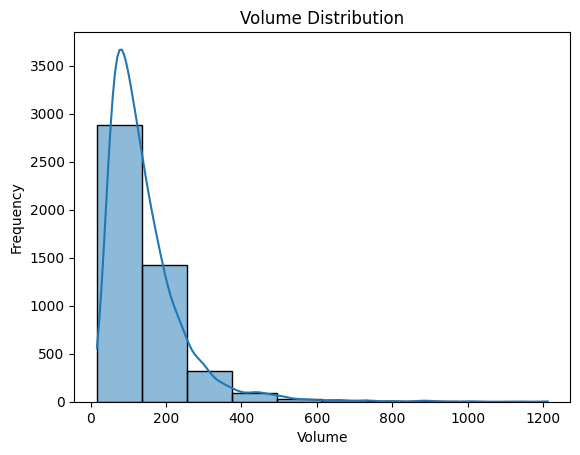

In [5]:
# import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# --- Plot histogram ---
sns.histplot(df['HL'], bins=10, kde=True)
# sns.histplot(df['OC'], bins=10, kde=True)
plt.title("Volume Distribution")
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.show()


2025-10-19 15:46:59,603 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-19 15:46:59,756 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


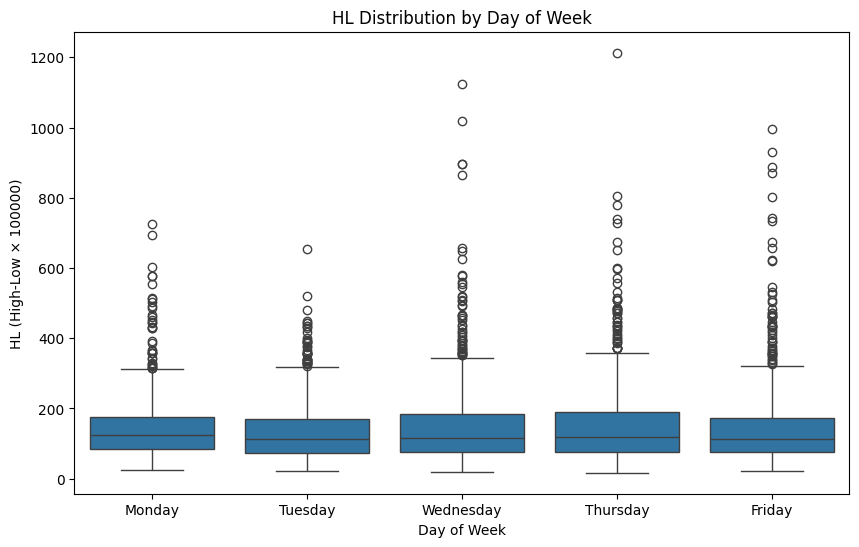

In [6]:
plt.figure(figsize=(10,6))
sns.boxplot(x='day', y='HL', data=df, order=['Monday','Tuesday','Wednesday','Thursday','Friday'])
plt.title("HL Distribution by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("HL (High-Low × 100000)")
plt.show()

In [7]:
df['HL_above_400'].sum()


np.int64(130)

In [8]:
heatmap_data = df.pivot_table(
    index='day',
    columns='hour',
    values='HL_above_400',
    aggfunc='sum'
)

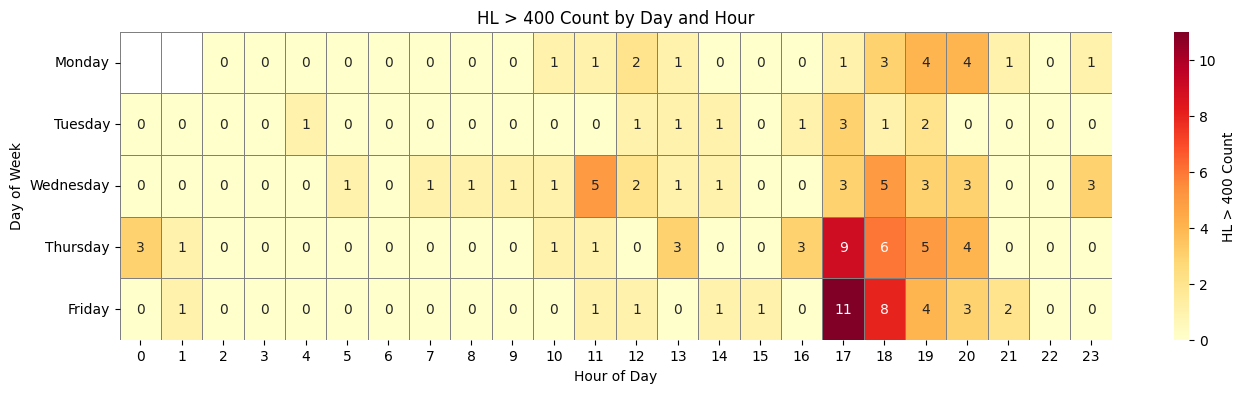

In [9]:
# Order days properly
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday']
heatmap_data = heatmap_data.reindex(days_order)

# -------------------------------
# 6. Plot heatmap
# -------------------------------
plt.figure(figsize=(16,4))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'HL > 400 Count'}
)
plt.title("HL > 400 Count by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

In [10]:
df_march = df_march.iloc[250:]

mask = df_march.index[df_march['HL_above_400'] == True]

print(mask)


DatetimeIndex(['2024-04-17 11:30:00+05:30', '2024-04-19 20:30:00+05:30',
               '2024-04-23 16:30:00+05:30', '2024-04-23 18:30:00+05:30',
               '2024-04-25 17:30:00+05:30', '2024-04-25 19:30:00+05:30',
               '2024-04-26 17:30:00+05:30', '2024-04-26 19:30:00+05:30',
               '2024-04-30 17:30:00+05:30'],
              dtype='datetime64[ns, Asia/Kolkata]', name='datetime', freq=None)


2025-10-19 15:47:06,675 [INFO] Generating chart 38bfdc16-bd66-4811-bd0d-207d55c07cdd with 261 data points
2025-10-19 15:47:06,888 [INFO] Chart 38bfdc16-bd66-4811-bd0d-207d55c07cdd generated successfully in 0.22s


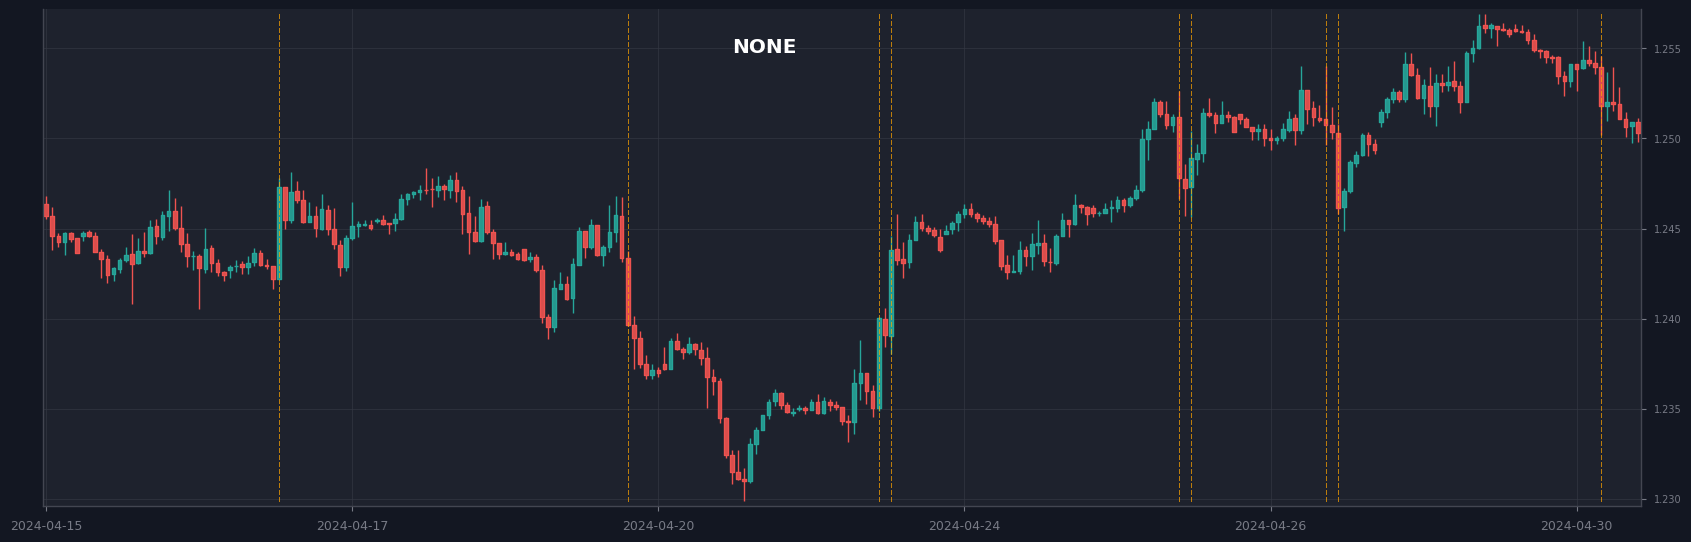

In [11]:
"""Creating The Main Chart"""

fig, axes =chartter.plot(
    df_march,
    config=cnf,
    vlines = {
        'vlines': mask.to_list(),
        'colors': 'orange',
        'linewidths': 0.9,
        'linestyle': '--',
        'alpha': 0.7
    },
    returnfig=True
)